
Missing values per column:
Tick        0
Throttle    0
Speed       0
Current     0
Voltage     0
Speed1      0
Time        0
TimePlot    0
dtype: int64


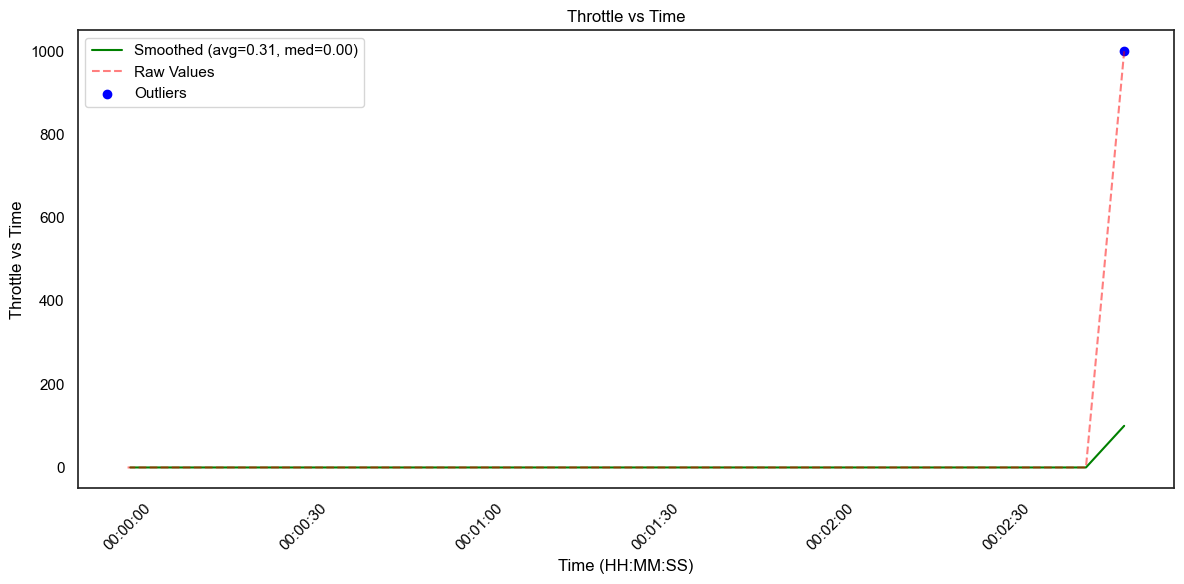

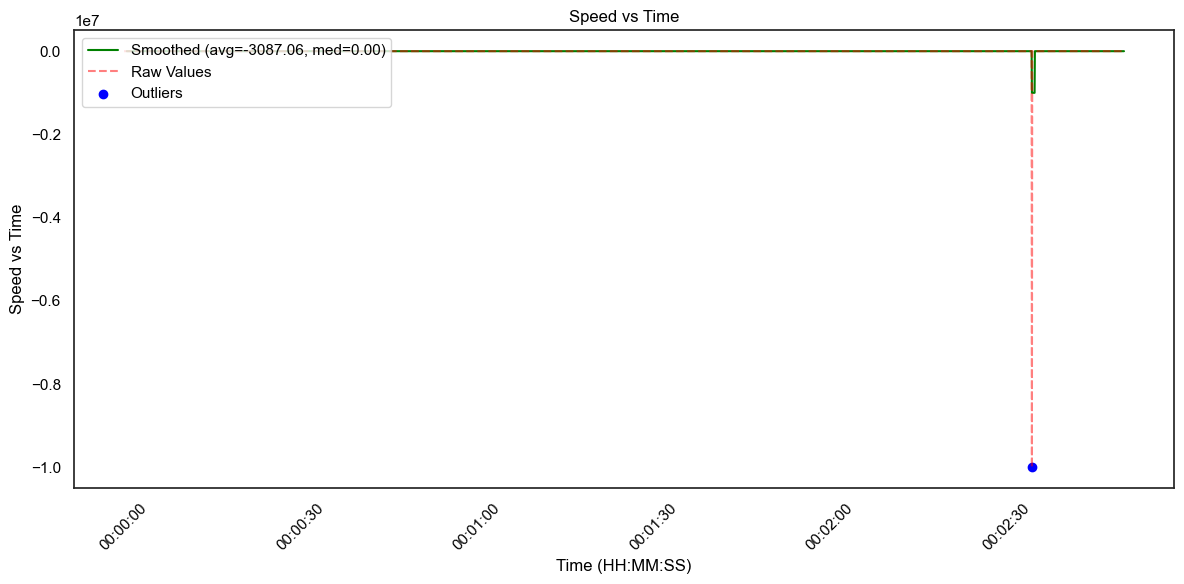

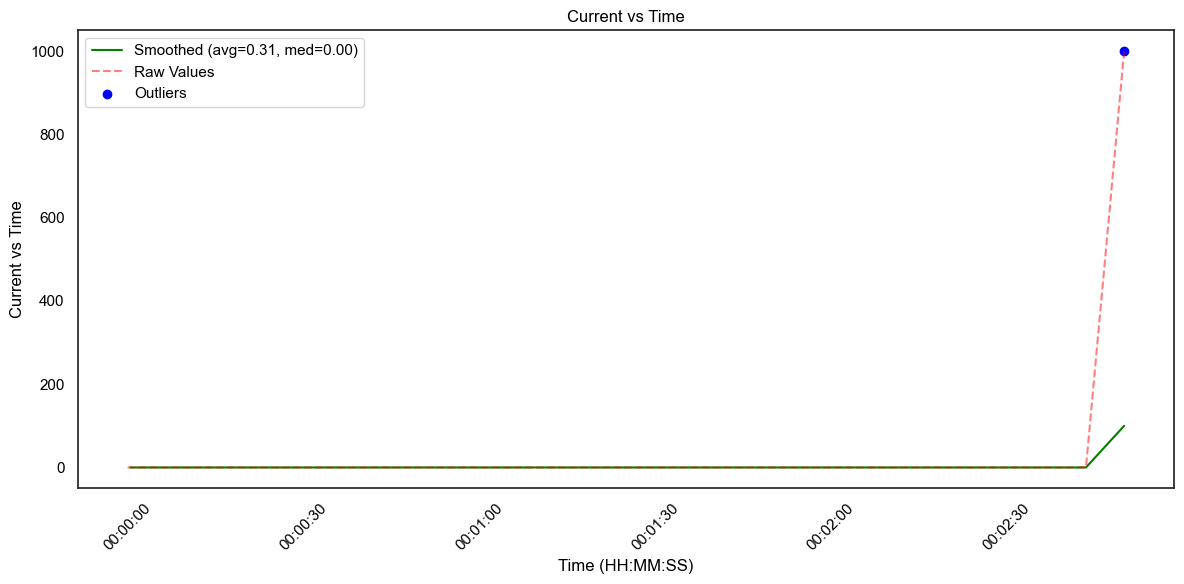

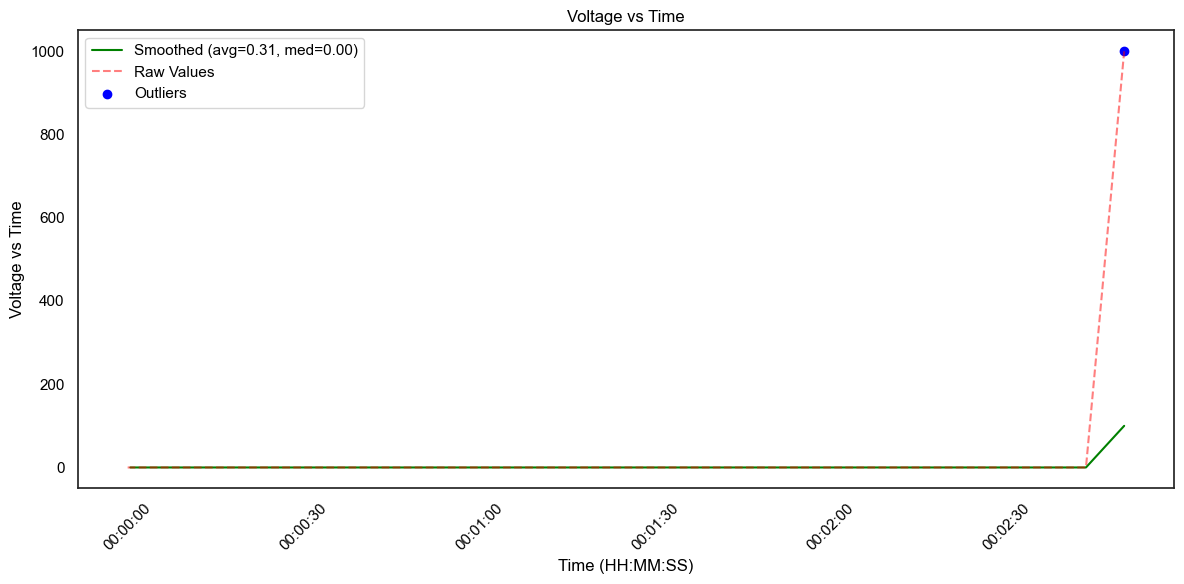

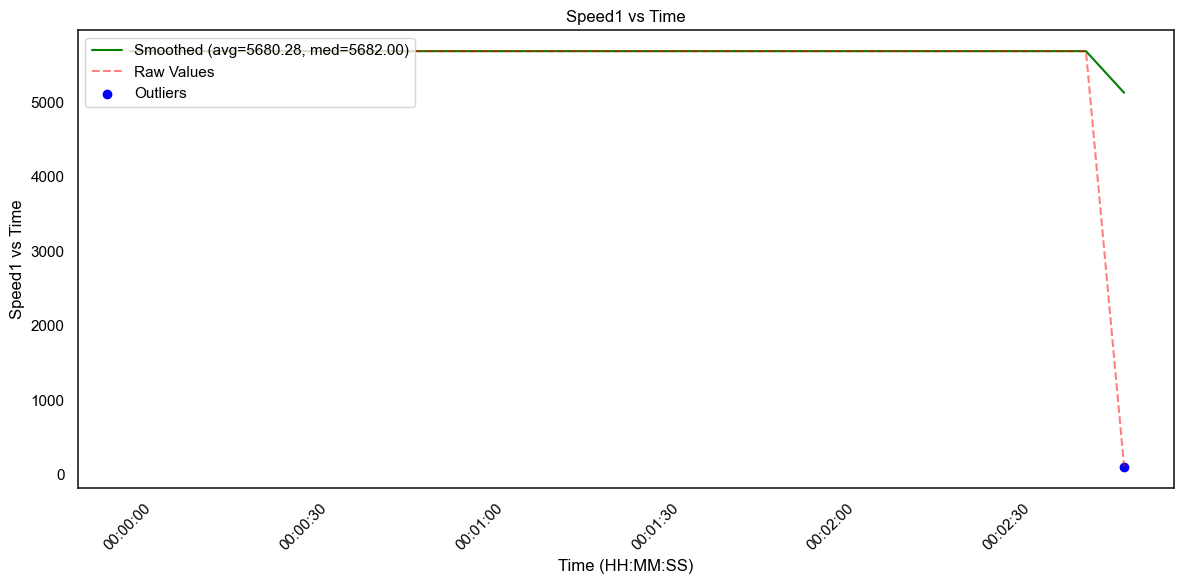

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore
import matplotlib.dates as mdates

sns.set(style='white')  # light background

# Load and clean data
data = pd.read_csv('d_14.csv')
data.columns = data.columns.str.strip()

# Convert Tick to time
data['Time'] = pd.to_timedelta(data['Tick'], unit='ms')
data['TimePlot'] = pd.Timestamp("2023-01-01") + data['Time']

# Check for missing values
print("\nMissing values per column:")
print(data.isnull().sum())

# Columns to visualize
columns_to_plot = ['Throttle', 'Speed', 'Current', 'Voltage', 'Speed1']
data.dropna(subset=['TimePlot'] + columns_to_plot, inplace=True)

# Plot each column
for col in columns_to_plot:
    if col in data.columns:
        x = data['TimePlot']
        y = data[col]
        y_smooth = y.rolling(window=10).mean()

        # Stats
        avg = y.mean()
        med = y.median()

        # Outliers (Z-score method)
        z_scores = zscore(y)
        outliers = np.abs(z_scores) > 2

        # Start plotting
        fig, ax = plt.subplots(figsize=(12, 6))

        # Smoothed line
        ax.plot(x, y_smooth, color='green', label=f'Smoothed (avg={avg:.2f}, med={med:.2f})')

        # Raw dashed line
        ax.plot(x, y, linestyle='--', color='red', alpha=0.5, label='Raw Values')

        # Outliers as blue dots
        ax.scatter(x[outliers], y[outliers], color='blue', label='Outliers')

        # Labeling and formatting
        ax.set_xlabel("Time (HH:MM:SS)", color='black')
        ax.set_ylabel(f"{col} vs Time", color='black')
        ax.set_title(f"{col} vs Time", color='black')
        ax.tick_params(axis='x', colors='black', rotation=45)
        ax.tick_params(axis='y', colors='black')

        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

        # Legend in black
        legend = ax.legend(loc='upper left')
        for text in legend.get_texts():
            text.set_color('black')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{col}' not found in dataset.")
